In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
import os
import sys

sys.path.append("..")

import matplotlib.cm as cm
import numpy as np
import torch
from matplotlib import pyplot as plt

from src.distributions import StandardNormalSampler, SwissRollSampler
from src.light_gcot import LightGCOT

In [ ]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

In [39]:
models = []
m_potentials = 200
n_potentials = 500
epsilon = 0.002
exp_cost = "double_uniform_on_circle_plus_x"
exp_cost_included = False
exp_meta_info = "_R=1_D=diag(0.1, 10)_R=2_D=diag(0.1, 10)"
max_steps = 20000

for eps in [epsilon]:
    EXP_NAME = (
        f"LightGCOT_Swiss_Roll_EPSILON_{eps}_MAX_STEPS_{max_steps}_N_{n_potentials}_M_{m_potentials}_with_{exp_cost}_cost_included_{exp_cost_included}"
        + exp_meta_info
    )
    OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)
    D = LightGCOT(
        x_dim=2,
        y_dim=2,
        n_potentials=n_potentials,
        m_potentials=m_potentials,
        epsilon=eps,
        A_diagonal_init=0.0001,
        is_B_diagonal=True,
        cost_function=exp_cost,
    )
    D.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D.pt")))
    models.append(D)

In [44]:
X_sampler = StandardNormalSampler(dim=2, device="cuda")
Y_sampler = SwissRollSampler(dim=2, device="cuda")

In [45]:
SEED = 12
torch.manual_seed(SEED)
np.random.seed(SEED)

In [46]:
NUM_SAMPLES = 1024
NUM_STARTING_POINTS = 2
colors_chosen = cm.rainbow(np.linspace(0.1, 0.9, NUM_STARTING_POINTS))

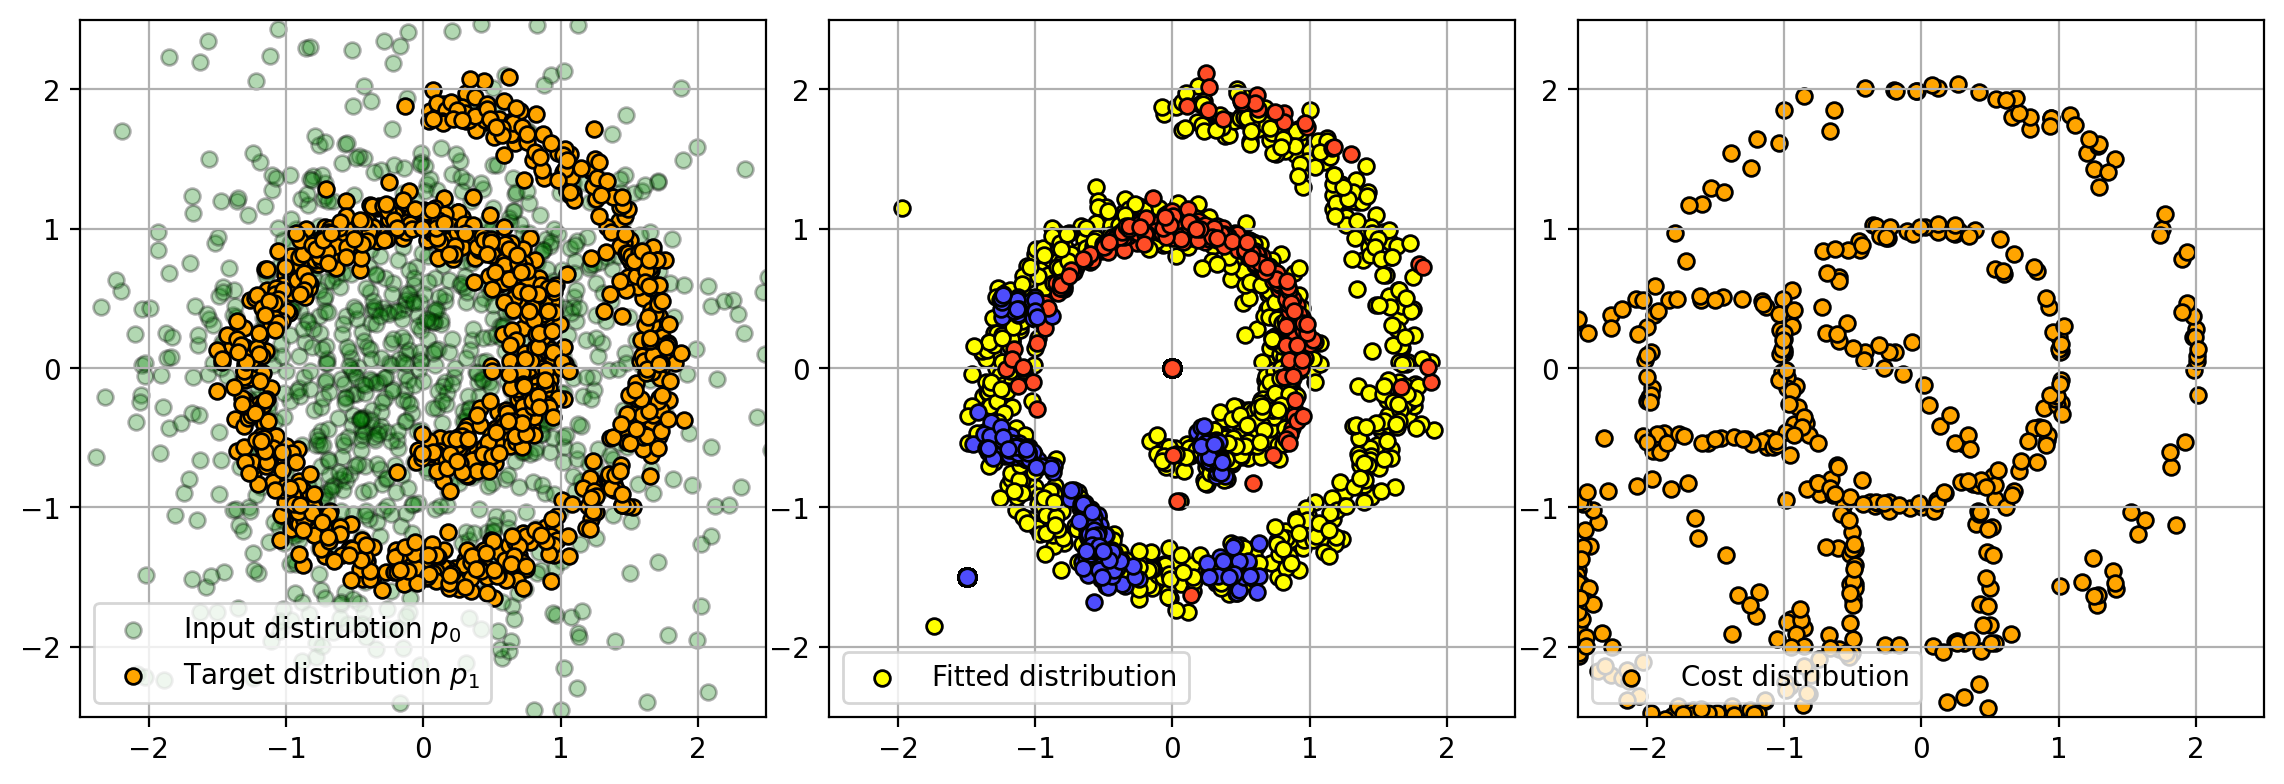

In [49]:
NUM_ENDING_POINTS = 256

fig, axes = plt.subplots(1, 3, figsize=(11.25, 3.75), dpi=200)

for ax in axes:
    ax.grid(zorder=-20)

x_samples = X_sampler.sample(NUM_SAMPLES)
y_samples = Y_sampler.sample(NUM_SAMPLES)
tr_samples = torch.tensor([[-1.5, -1.5], [0.0, 0.0], [1.0, -2.0], [-1.5, 1.25], [1.5, 2.0]])[:NUM_STARTING_POINTS]

tr_samples = tr_samples[None].repeat(NUM_ENDING_POINTS, 1, 1).reshape(NUM_ENDING_POINTS * NUM_STARTING_POINTS, 2)

axes[0].scatter(
    x_samples[:, 0].cpu().numpy(),
    x_samples[:, 1].cpu().numpy(),
    alpha=0.3,
    c="g",
    s=32,
    edgecolors="black",
    label=r"Input distirubtion $p_0$",
)
axes[0].scatter(
    y_samples[:, 0].cpu().numpy(),
    y_samples[:, 1].cpu().numpy(),
    c="orange",
    s=32,
    edgecolors="black",
    label=r"Target distribution $p_1$",
)


b_m = D.compute_b_m(tr_samples)
B_m = D.compute_B_m(tr_samples)
log_v_m = D.compute_log_v_m(tr_samples)
y_cost_sample = D.compute_cost(b_m, B_m, log_v_m, sample=True).cpu().numpy()
axes[2].scatter(
    y_cost_sample[:, 0], y_cost_sample[:, 1], c="orange", s=32, edgecolors="black", label=r"Cost distribution"
)

for ax, model in zip(axes[1:], models):
    y_pred = model(x_samples).cpu().numpy()

    ax.scatter(y_pred[:, 0], y_pred[:, 1], c="yellow", s=32, edgecolors="black", label="Fitted distribution", zorder=1)

    tr_samples_pred = model(tr_samples).cpu().numpy()
    for i in range(NUM_ENDING_POINTS):
        for j, (point, point_pred) in enumerate(
            zip(
                tr_samples[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS].cpu().numpy(),
                tr_samples_pred[i * NUM_STARTING_POINTS : (i + 1) * NUM_STARTING_POINTS],
            )
        ):
            ax.scatter(
                point[0],
                point[1],
                color=colors_chosen[j],
                s=40,
                # label=r"Trajectory start ($x \sim p_0$)",
                zorder=3,
                edgecolors="black",
            )
            ax.scatter(
                point_pred[0],
                point_pred[1],
                color=colors_chosen[j],
                s=32,
                # label=r"Trajectory end ($x \sim p_1$)",
                zorder=3,
                edgecolors="black",
            )
            # ax.arrow(
            #     point[0],
            #     point[1],
            #     point_pred[0] - point[0],
            #     point_pred[1] - point[1],
            # )


for i, ax in enumerate(axes):
    ax.set_xlim([-2.5, 2.5])
    ax.set_ylim([-2.5, 2.5])
    ax.legend(loc="lower left")

fig.tight_layout(pad=0.1)